[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/purva-thakre/qce26-qrisp/blob/main/Session_2_Introduction_to_Jasp/BonusMaterial/XLABackend.ipynb)

# XLA Backend

Once `jax.jit` traces a function, the real work moves into XLA: turning that trace into an intermediate representation, then into actual machine code for whatever backend you're running on. 

In this notebook we look at what the intermediate form looks like, how XLA optimizes it (fusion especially), and how the same code ends up as different machine code on different hardware.

## Setup

In [1]:
!pip install qrisp

In [2]:
import jax
import jax.numpy as jnp

## Inspecting the StableHLO Output

The `JaspJIT.ipynb` notebook already used `.lower(...).as_text(dialect=...)` briefly, to contrast StableHLO against HLO. Here we stay at exactly that layer and go further.

`jax.jit(f).lower(...)` stops right before compilation and hands back XLA's intermediate representation (StableHLO) as plain text.

It's the clearest way to see exactly what our function turned into, before any hardware-specific optimization happens.

In [3]:
def f(x):
    return jnp.sin(x) + jnp.cos(x)

In [4]:
# Get the StableHLO representation for this function
lowered = jax.jit(f).lower(jnp.ones(4))
print(lowered.as_text())

module @jit_f attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
  func.func public @main(%arg0: tensor<4xf32>) -> (tensor<4xf32> {jax.result_info = "result"}) {
    %0 = stablehlo.sine %arg0 : tensor<4xf32>
    %1 = stablehlo.cosine %arg0 : tensor<4xf32>
    %2 = stablehlo.add %0, %1 : tensor<4xf32>
    return %2 : tensor<4xf32>
  }
}



Observations:

- Notice how closely this mirrors the Python: `sin`, `cos`, `add` become `stablehlo.sine`, `stablehlo.cosine`, `stablehlo.add`, each acting on the whole array at once with no explicit loops.

- This is the same idea as the jaxpr from `JaspTracing.ipynb`, just one level further down the pipeline: the same three operations, now expressed in XLA's own typed dialect instead of JAX's.

## A More Involved StableHLO: Softmax

Softmax brings in reductions (`max`, `sum`) on top of elementwise ops, so its StableHLO is a more realistic taste of what real code compiles down to.

We should watch for `reduce` and `broadcast_in_dim`, op kinds that didn't show up in the first example.

In [5]:
def softmax(x):
    x_shifted = x - jnp.max(x)
    e_x = jnp.exp(x_shifted)
    return e_x / jnp.sum(e_x)

In [6]:
lowered = jax.jit(softmax).lower(jnp.ones(4))
print(lowered.as_text())

module @jit_softmax attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
  func.func public @main(%arg0: tensor<4xf32>) -> (tensor<4xf32> {jax.result_info = "result"}) {
    %cst = stablehlo.constant dense<0xFF800000> : tensor<f32>
    %0 = stablehlo.reduce(%arg0 init: %cst) applies stablehlo.maximum across dimensions = [0] : (tensor<4xf32>, tensor<f32>) -> tensor<f32>
    %1 = stablehlo.broadcast_in_dim %0, dims = [] : (tensor<f32>) -> tensor<4xf32>
    %2 = stablehlo.subtract %arg0, %1 : tensor<4xf32>
    %3 = stablehlo.exponential %2 : tensor<4xf32>
    %cst_0 = stablehlo.constant dense<0.000000e+00> : tensor<f32>
    %4 = stablehlo.reduce(%3 init: %cst_0) applies stablehlo.add across dimensions = [0] : (tensor<4xf32>, tensor<f32>) -> tensor<f32>
    %5 = stablehlo.broadcast_in_dim %4, dims = [] : (tensor<f32>) -> tensor<4xf32>
    %6 = stablehlo.divide %3, %5 : tensor<4xf32>
    return %6 : tensor<4xf32>
  }
}



Observations:

- You can read this straight off the stable-softmax formula: reduce to a max, broadcast it back out, subtract, exponentiate, reduce to a sum, broadcast, divide.

- The two reduction constants are each op's identity element: `0xFF800000` is `-inf` in float32 bit pattern (the identity for `maximum`), and the second constant is plain `0.0` (the identity for `add`).

## Observing Operator Fusion

Now we use the same chain of elementwise ops (`sin`, `exp`, times 2, `tanh`) written twice: once in plain NumPy, once in JAX.

Timing both will show what operator fusion is actually worth; the StableHLO afterwards will show why.

In [7]:
import time
import numpy as np


def elementwise_chain_numpy(x):
    x = np.sin(x)
    x = np.exp(x)
    x = x * 2.0
    x = np.tanh(x)
    return x


def elementwise_chain_jax(x):
    x = jnp.sin(x)
    x = jnp.exp(x)
    x = x * 2.0
    x = jnp.tanh(x)
    return x


elementwise_chain_jit = jax.jit(elementwise_chain_jax)

In [8]:
x_np = np.ones((2000, 2000))
x_jnp = jnp.ones((2000, 2000))
_ = elementwise_chain_jit(
    x_jnp
).block_until_ready()  # warm-up: compiles now, so the timed loop below doesn't pay for it

In [9]:
start = time.perf_counter()
for _ in range(10):
    elementwise_chain_numpy(x_np)
print(f"NumPy (no fusion): {(time.perf_counter() - start) / 10 * 1000:.2f} ms per call")

NumPy (no fusion): 67.30 ms per call


In [10]:
start = time.perf_counter()
for _ in range(10):
    elementwise_chain_jit(x_jnp).block_until_ready()
print(f"JAX JIT (fused): {(time.perf_counter() - start) / 10 * 1000:.2f} ms per call")

JAX JIT (fused): 12.92 ms per call


JIT comes out clearly ahead here, fused into a single kernel, XLA reads and writes the array once for the whole chain, while NumPy re-reads and re-writes it at every line.

In [11]:
lowered = jax.jit(elementwise_chain_jax).lower(x_jnp)
print(lowered.as_text())

module @jit_elementwise_chain_jax attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
  func.func public @main(%arg0: tensor<2000x2000xf32>) -> (tensor<2000x2000xf32> {jax.result_info = "result"}) {
    %0 = stablehlo.sine %arg0 : tensor<2000x2000xf32>
    %1 = stablehlo.exponential %0 : tensor<2000x2000xf32>
    %cst = stablehlo.constant dense<2.000000e+00> : tensor<f32>
    %2 = stablehlo.broadcast_in_dim %cst, dims = [] : (tensor<f32>) -> tensor<2000x2000xf32>
    %3 = stablehlo.multiply %1, %2 : tensor<2000x2000xf32>
    %4 = stablehlo.tanh %3 : tensor<2000x2000xf32>
    return %4 : tensor<2000x2000xf32>
  }
}



This is why fusion is possible: `sine → exponential → multiply → tanh` sit back-to-back with nothing forcing a trip to memory in between, exactly the shape XLA collapses into one kernel once compiled.

## Compilation from StableHLO to Machine Code

The `.lower()` method gets us StableHLO: hardware-agnostic, not runnable yet. `.compile()` is the step where XLA actually targets our machine and hands back something we can run.

The `Compiled` object below is that something: the same kind of executable `jax.jit` builds and caches behind the scenes on every ordinary call. Here we just walk through `lower` -> `compile` by hand instead of leaving it implicit inside `jit`.

In [12]:
@jax.jit
def f(x):  # reusing the name f for a fresh demo
    return jnp.sum(jnp.sin(x) ** 2)

In [13]:
lowered = f.lower(jnp.ones(4))
print(lowered.as_text())

module @jit_f attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
  func.func public @main(%arg0: tensor<4xf32>) -> (tensor<f32> {jax.result_info = "result"}) {
    %0 = stablehlo.sine %arg0 : tensor<4xf32>
    %1 = stablehlo.multiply %0, %0 : tensor<4xf32>
    %cst = stablehlo.constant dense<0.000000e+00> : tensor<f32>
    %2 = stablehlo.reduce(%1 init: %cst) applies stablehlo.add across dimensions = [0] : (tensor<4xf32>, tensor<f32>) -> tensor<f32>
    return %2 : tensor<f32>
  }
}



In [14]:
compiled = lowered.compile()
print(f"compiled: {compiled}")
print(f"type(compiled): {type(compiled).__name__}")

compiled: <jax._src.stages.Compiled object at 0x74120cb3a4b0>
type(compiled): Compiled


Here's the raw attribute surface a `Compiled` object exposes:

In [15]:
dir(compiled)

['__annotations__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_call',
 '_executable',
 '_input_layouts_flat',
 '_input_shardings_flat',
 '_no_kwargs',
 '_output_formats_flat',
 '_params',
 'args_info',
 'as_text',
 'call',
 'cost_analysis',
 'donate_argnums',
 'in_avals',
 'in_tree',
 'input_formats',
 'input_shardings',
 'memory_analysis',
 'out_info',
 'out_tree',
 'output_formats',
 'output_shardings',
 'runtime_executable']

Observations:

- `as_text()` returns the compiled HLO as text: the same kind of dump `.lower().as_text()` gave us for StableHLO, but now past compilation, with concrete backend-specific detail baked in.

- `cost_analysis()` and `memory_analysis()` expose XLA's own resource estimates for the compiled program: FLOPs, bytes accessed, output size, and similar.

- It's directly callable, via `__call__`: exactly what the next cell does.

In [16]:
compiled(jnp.ones(4))

Array(2.8322935, dtype=float32)

## XLA on Different Hardware

The same jitted function can be compiled for CPU, GPU, or TPU. XLA has a separate backend per target, and none of our JAX code has to change.

Below we just check what's available on this machine and time a matmul on it.

In [17]:
print(f"Available devices: {jax.devices()}")
print(f"Default backend: {jax.default_backend()}")

Available devices: [CpuDevice(id=0)]
Default backend: cpu


In [18]:
@jax.jit
def matmul(A, B):
    return A @ B


A = jnp.ones((512, 512))
B = jnp.ones((512, 512))

start = time.perf_counter()
for _ in range(20):
    matmul(A, B).block_until_ready()
print(
    f"Matrix multiply ({jax.default_backend()}): {(time.perf_counter() - start) / 20 * 1000:.2f} ms per call"
)

Matrix multiply (cpu): 2.29 ms per call


The number itself isn't the point. The same `matmul`, unmodified, would run on any backend XLA supports; only the generated machine code changes underneath.

## Layout Assignment: Watching the Backend Decide

StableHLO describes *what* to compute, not *how* it sits in memory. Concrete physical layouts get decided during compilation, not lowering.

Let's keep an eye on the `transpose` below, then see what's left of it once we actually compile.

In [19]:
@jax.jit
def matmul(A, B):  # reusing the name matmul for a fresh demo
    return A @ B.T

In [20]:
lowered = matmul.lower(jnp.ones((3, 4)), jnp.ones((3, 4)))
print(lowered.as_text())

module @jit_matmul attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
  func.func public @main(%arg0: tensor<3x4xf32>, %arg1: tensor<3x4xf32>) -> (tensor<3x3xf32> {jax.result_info = "result"}) {
    %0 = stablehlo.transpose %arg1, dims = [1, 0] : (tensor<3x4xf32>) -> tensor<4x3xf32>
    %1 = stablehlo.dot_general %arg0, %0, contracting_dims = [1] x [0], precision = [DEFAULT, DEFAULT] : (tensor<3x4xf32>, tensor<4x3xf32>) -> tensor<3x3xf32>
    return %1 : tensor<3x3xf32>
  }
}



In [21]:
compiled = lowered.compile()
print(f"compiled as text: {compiled.as_text()}")

compiled as text: HloModule jit_matmul, is_scheduled=true, entry_computation_layout={(f32[3,4]{1,0}, f32[3,4]{1,0})->f32[3,3]{1,0}}, allow_spmd_sharding_propagation_to_parameters={true,true}, allow_spmd_sharding_propagation_to_output={true}

ENTRY %main.5 (A.1: f32[3,4], B.2: f32[3,4]) -> f32[3,3] {
  %A.1 = f32[3,4]{1,0} parameter(0), metadata={op_name="A"}
  %B.2 = f32[3,4]{1,0} parameter(1), metadata={op_name="B"}
  ROOT %dot_general.4 = f32[3,3]{1,0} dot(%A.1, %B.2), lhs_contracting_dims={1}, rhs_contracting_dims={1}, metadata={op_name="jit(matmul)/dot_general" source_file="/tmp/ipykernel_14686/3311875142.py" source_line=3 source_end_line=3 source_column=11 source_end_column=18}
}




Observations:

- The explicit `transpose` from the StableHLO is nowhere to be found here. XLA realized it can just contract along `B`'s other dimension instead of physically transposing it first. The backend picked a cheaper physical execution than the one literally written in the source.

- Notice each shape now carries a concrete layout too, e.g. `f32[3,4]{1,0}`. The `{1,0}` is the physical (minor-to-major) dimension order XLA assigned. StableHLO's `tensor<3x4xf32>` above had no such thing: layout is exactly the kind of hardware-specific detail that only gets decided at compilation.

- This is also genuine HLO text, not StableHLO. The same distinction `JaspJIT.ipynb` drew between the two dialects: `.lower().as_text()` gives portable StableHLO, `.compile().as_text()` gives XLA's own internal form.

## Benchmarking the Price of Fusion

The `chain` function below just repeats one cheap elementwise step `k` times: bigger `k` means more fusable work per call.

Here, `k` is passed as a static arg, so `chain_jit` recompiles for each new value. The warm-up call before each timed loop pays for that, not the timing itself.

In [22]:
def chain(x, k):
    for _ in range(k):
        x = 0.25 * x**3 + 0.75 * x
    return x


chain_jit = jax.jit(
    chain, static_argnums=1
)  # k is static: a different k means a different unrolled chain, so a different jaxpr

In [23]:
x = jnp.ones((2000, 2000))
ks = [1, 2, 4, 8, 16, 32]
eager_ms, jit_ms = [], []

In [24]:
for k in ks:
    _ = chain(x, k).block_until_ready()
    start = time.perf_counter()
    for _ in range(20):
        chain(x, k).block_until_ready()
    eager_ms.append((time.perf_counter() - start) / 20 * 1000)

    _ = chain_jit(
        x, k
    ).block_until_ready()  # k is static, so this recompiles for the new k, kept out of the timed loop
    start = time.perf_counter()
    for _ in range(20):
        chain_jit(x, k).block_until_ready()
    jit_ms.append((time.perf_counter() - start) / 20 * 1000)

    print(f"k={k:2d}: eager {eager_ms[-1]:7.2f} ms | jit {jit_ms[-1]:6.2f} ms")

k= 1: eager   11.84 ms | jit   1.18 ms


k= 2: eager   18.04 ms | jit   0.96 ms


k= 4: eager   34.41 ms | jit   1.10 ms


k= 8: eager   67.17 ms | jit   1.67 ms


k=16: eager  164.43 ms | jit   3.89 ms


k=32: eager  311.58 ms | jit   6.74 ms


Observations:

- Eager time climbs with `k`: every extra step is its own separate pass over the array, so the cost scales with how many steps there are.

- JIT time grows far more slowly. Fused into one kernel, extra elementwise steps are almost free within the same memory pass rather than each paying for its own.

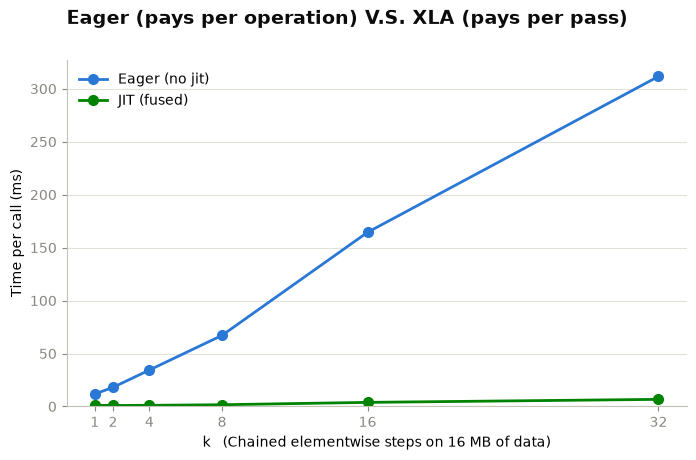

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))

ax.plot(
    ks,
    eager_ms,
    color="#2a78d6",
    linewidth=2,
    marker="o",
    markersize=7,
    label="Eager (no jit)",
)
ax.plot(
    ks,
    jit_ms,
    color="#008300",
    linewidth=2,
    marker="o",
    markersize=7,
    label="JIT (fused)",
)

ax.set_xticks(ks)
ax.set_xlabel("k   (Chained elementwise steps on 16 MB of data)")
ax.set_ylabel("Time per call (ms)")
ax.set_title(
    "Eager (pays per operation) V.S. XLA (pays per pass)",
    loc="left",
    fontsize=14,
    fontweight="bold",
    color="#0b0b0b",
    pad=26,
)

ax.legend(frameon=False, loc="upper left")
ax.grid(axis="y", color="#e1e0d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#c3c2b7")
ax.tick_params(colors="#898781")
ax.set_ylim(bottom=0)

plt.show()